In [1]:
import pandas as pd

neighbourhood = pd.read_csv(
    "../data/processed/neighbourhood_demand.csv"
)

neighbourhood["datetime"] = pd.to_datetime(
    neighbourhood["datetime"]
)

neighbourhood = neighbourhood[
    neighbourhood["datetime"] >= "2013-01-01"
].copy()

stress_threshold = (
    neighbourhood["total_demand_kwh"]
    .quantile(0.95)
)

print("Stress Threshold:", stress_threshold)

Stress Threshold: 354.5756


In [2]:
neighbourhood["stress_event"] = (
    neighbourhood["total_demand_kwh"]
    > stress_threshold
).astype(int)

stress_count = neighbourhood["stress_event"].sum()

print("Stress Events:", stress_count)

stress_percentage = (
    stress_count / len(neighbourhood)
) * 100

print("Stress Percentage:", stress_percentage)

Stress Events: 1016
Stress Percentage: 5.003693671509481


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Path("../outputs/tables").mkdir(parents=True, exist_ok=True)
Path("../outputs/figures").mkdir(parents=True, exist_ok=True)

In [2]:
neighbourhood = pd.read_csv(
    "../data/processed/model_ready_data.csv"
)

neighbourhood["datetime"] = pd.to_datetime(
    neighbourhood["datetime"]
)

neighbourhood = (
    neighbourhood
    .sort_values("datetime")
    .reset_index(drop=True)
)

print("Dataset shape:", neighbourhood.shape)
neighbourhood.head()

Dataset shape: (20209, 13)


,datetime,total_demand_kwh,hour,day,month,weekday,is_weekend,season,lag_1,lag_48,lag_96,rolling_mean_48,rolling_std_48
0,2013-01-03 00:00:00,209.864,0,3,1,3,0,0,243.522,198.338,220.013,240.736854,91.920733
1,2013-01-03 00:30:00,175.020,0,3,1,3,0,0,209.864,165.862,204.270,240.927646,91.771399
2,2013-01-03 01:00:00,151.394,1,3,1,3,0,0,175.020,147.971,189.439,240.998958,91.698930
3,2013-01-03 01:30:00,137.672,1,3,1,3,0,0,151.394,129.889,173.019,241.161104,91.504956
4,2013-01-03 02:00:00,128.217,2,3,1,3,0,0,137.672,117.542,154.537,241.383500,91.210616


In [3]:
print(
    neighbourhood["total_demand_kwh"]
    .describe()
)

print(
    "\nMissing target values:",
    neighbourhood["total_demand_kwh"].isna().sum()
)

count    20209.000000
mean       204.039879
std         77.170856
min         83.190000
25%        143.114000
50%        196.912000
75%        249.083000
max        464.916000
Name: total_demand_kwh, dtype: float64

Missing target values: 0


In [4]:
neighbourhood = neighbourhood.dropna(
    subset=["total_demand_kwh"]
).reset_index(drop=True)

print("Remaining observations:", len(neighbourhood))

Remaining observations: 20209


In [5]:
stress_percentile = 0.95

stress_threshold = neighbourhood[
    "total_demand_kwh"
].quantile(stress_percentile)

print(
    f"95th percentile stress threshold: "
    f"{stress_threshold:.4f} kWh"
)

95th percentile stress threshold: 354.1552 kWh


In [6]:
neighbourhood["stress_event"] = (
    neighbourhood["total_demand_kwh"]
    > stress_threshold
).astype(int)

neighbourhood[
    ["datetime", "total_demand_kwh", "stress_event"]
].head()

,datetime,total_demand_kwh,stress_event
0,2013-01-03 00:00:00,209.864,0
1,2013-01-03 00:30:00,175.020,0
2,2013-01-03 01:00:00,151.394,0
3,2013-01-03 01:30:00,137.672,0
4,2013-01-03 02:00:00,128.217,0


In [7]:
total_observations = len(neighbourhood)

stress_events = int(
    neighbourhood["stress_event"].sum()
)

stress_percentage = (
    stress_events / total_observations
) * 100

print("Total observations:", total_observations)
print("Stress events:", stress_events)
print(f"Stress percentage: {stress_percentage:.4f}%")

Total observations: 20209
Stress events: 1011
Stress percentage: 5.0027%


In [8]:
stress_summary = pd.DataFrame({
    "Metric": [
        "Stress percentile",
        "Stress threshold (kWh)",
        "Total observations",
        "Stress events",
        "Non-stress observations",
        "Stress percentage (%)"
    ],
    "Value": [
        stress_percentile * 100,
        stress_threshold,
        total_observations,
        stress_events,
        total_observations - stress_events,
        stress_percentage
    ]
})

stress_summary

,Metric,Value
0,Stress percentile,95.000000
1,Stress threshold (kWh),354.155200
2,Total observations,20209.000000
3,Stress events,1011.000000
4,Non-stress observations,19198.000000
5,Stress percentage (%),5.002722


In [9]:
stress_summary.to_csv(
    "../outputs/tables/stress_detection_summary.csv",
    index=False
)

print("Stress summary saved.")

Stress summary saved.


In [10]:
stress_output = neighbourhood[
    [
        "datetime",
        "total_demand_kwh",
        "stress_event"
    ]
].copy()

stress_output.to_csv(
    "../outputs/tables/stress_events.csv",
    index=False
)

print("Stress event dataset saved.")

Stress event dataset saved.


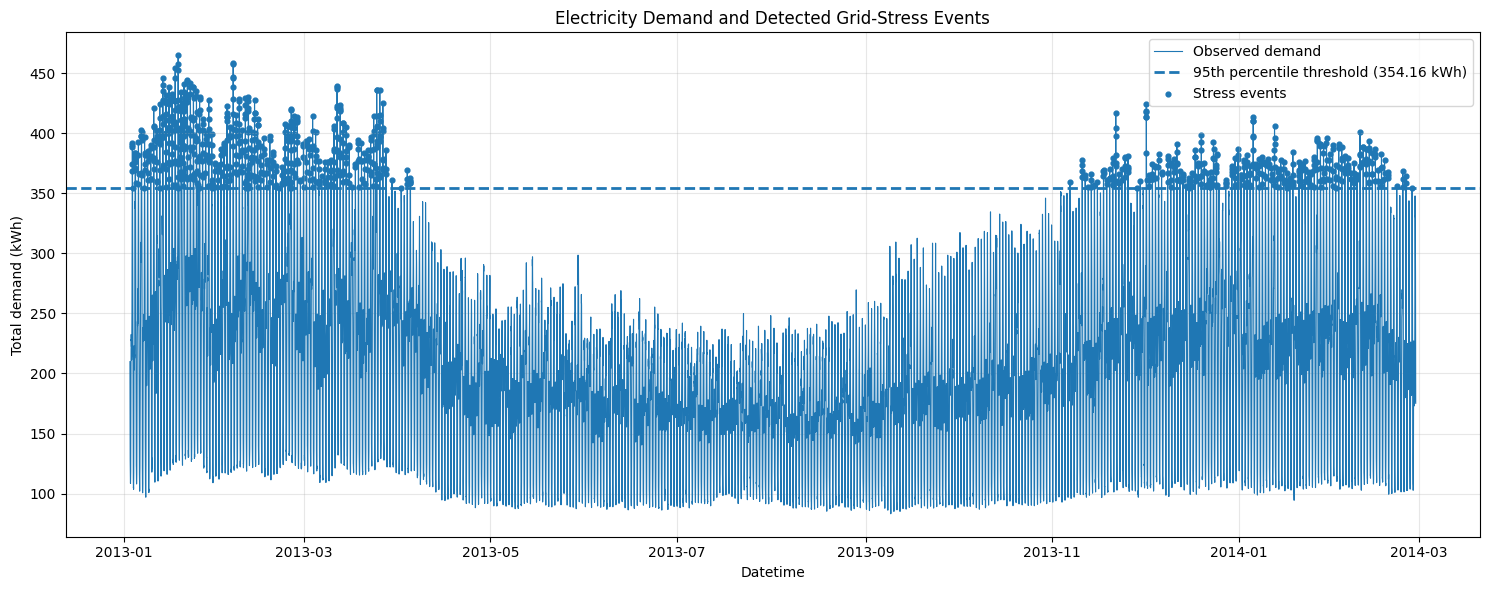

In [11]:
plt.figure(figsize=(15, 6))

plt.plot(
    neighbourhood["datetime"],
    neighbourhood["total_demand_kwh"],
    linewidth=0.8,
    label="Observed demand"
)

plt.axhline(
    y=stress_threshold,
    linestyle="--",
    linewidth=2,
    label=f"95th percentile threshold ({stress_threshold:.2f} kWh)"
)

stress_points = neighbourhood[
    neighbourhood["stress_event"] == 1
]

plt.scatter(
    stress_points["datetime"],
    stress_points["total_demand_kwh"],
    s=12,
    label="Stress events"
)

plt.title(
    "Electricity Demand and Detected Grid-Stress Events"
)
plt.xlabel("Datetime")
plt.ylabel("Total demand (kWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/stress_detection_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

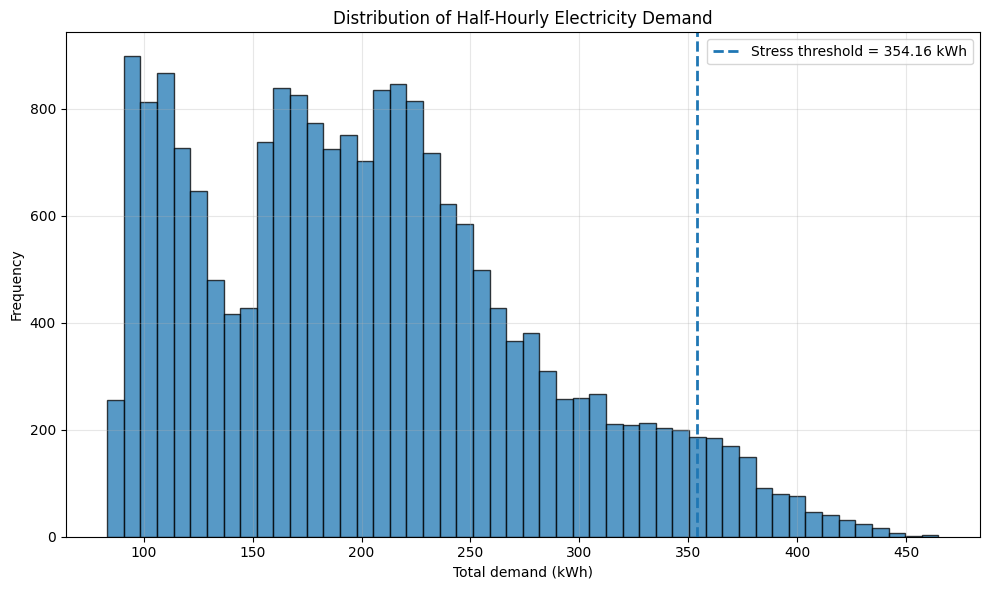

In [12]:
plt.figure(figsize=(10, 6))

plt.hist(
    neighbourhood["total_demand_kwh"],
    bins=50,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    stress_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Stress threshold = {stress_threshold:.2f} kWh"
)

plt.title(
    "Distribution of Half-Hourly Electricity Demand"
)
plt.xlabel("Total demand (kWh)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/stress_demand_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
neighbourhood["year_month"] = (
    neighbourhood["datetime"]
    .dt.to_period("M")
    .astype(str)
)

monthly_stress = (
    neighbourhood
    .groupby("year_month")
    .agg(
        total_observations=("stress_event", "size"),
        stress_events=("stress_event", "sum"),
        mean_demand_kwh=("total_demand_kwh", "mean"),
        maximum_demand_kwh=("total_demand_kwh", "max")
    )
    .reset_index()
)

monthly_stress["stress_percentage"] = (
    monthly_stress["stress_events"]
    / monthly_stress["total_observations"]
) * 100

monthly_stress.head()

,year_month,total_observations,stress_events,mean_demand_kwh,maximum_demand_kwh,stress_percentage
0,2013-01,1392,270,253.972736,464.916,19.396552
1,2013-02,1344,197,247.920759,458.238,14.657738
2,2013-03,1488,154,242.007011,439.335,10.349462
3,2013-04,1440,9,198.359103,369.213,0.625000
4,2013-05,1488,0,176.928978,298.531,0.000000


In [14]:
monthly_stress.to_csv(
    "../outputs/tables/monthly_stress_analysis.csv",
    index=False
)

print("Monthly stress analysis saved.")

Monthly stress analysis saved.


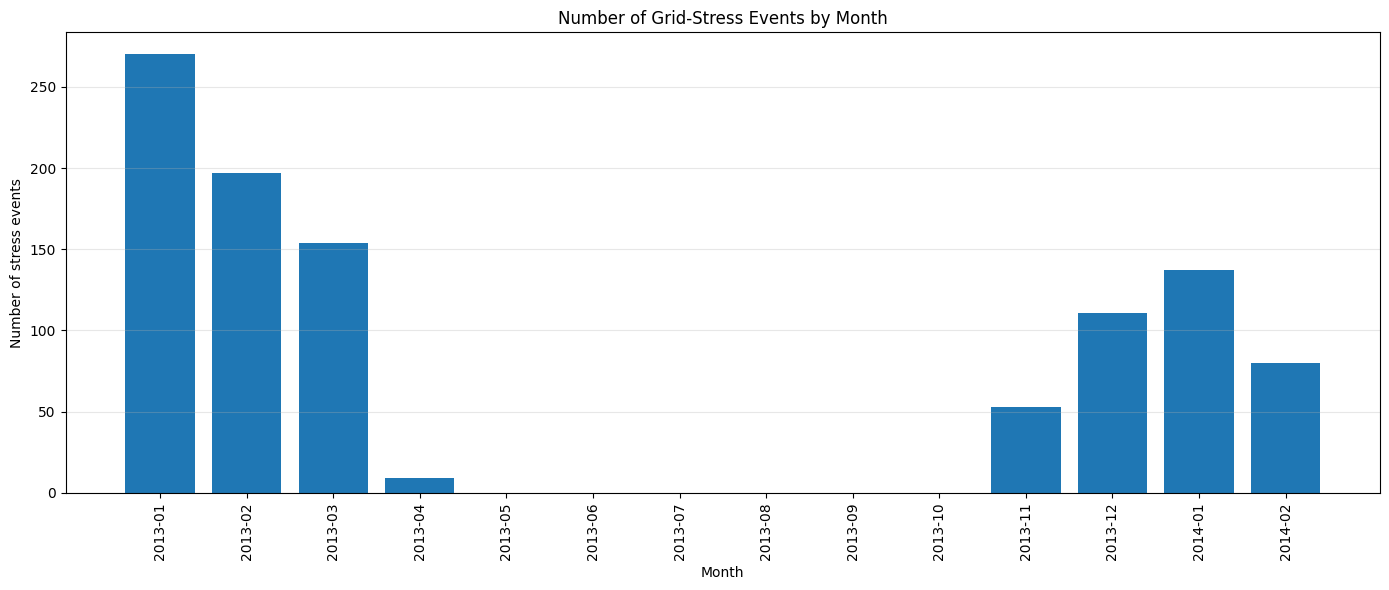

In [15]:
plt.figure(figsize=(14, 6))

plt.bar(
    monthly_stress["year_month"],
    monthly_stress["stress_events"]
)

plt.title("Number of Grid-Stress Events by Month")
plt.xlabel("Month")
plt.ylabel("Number of stress events")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/monthly_stress_events.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

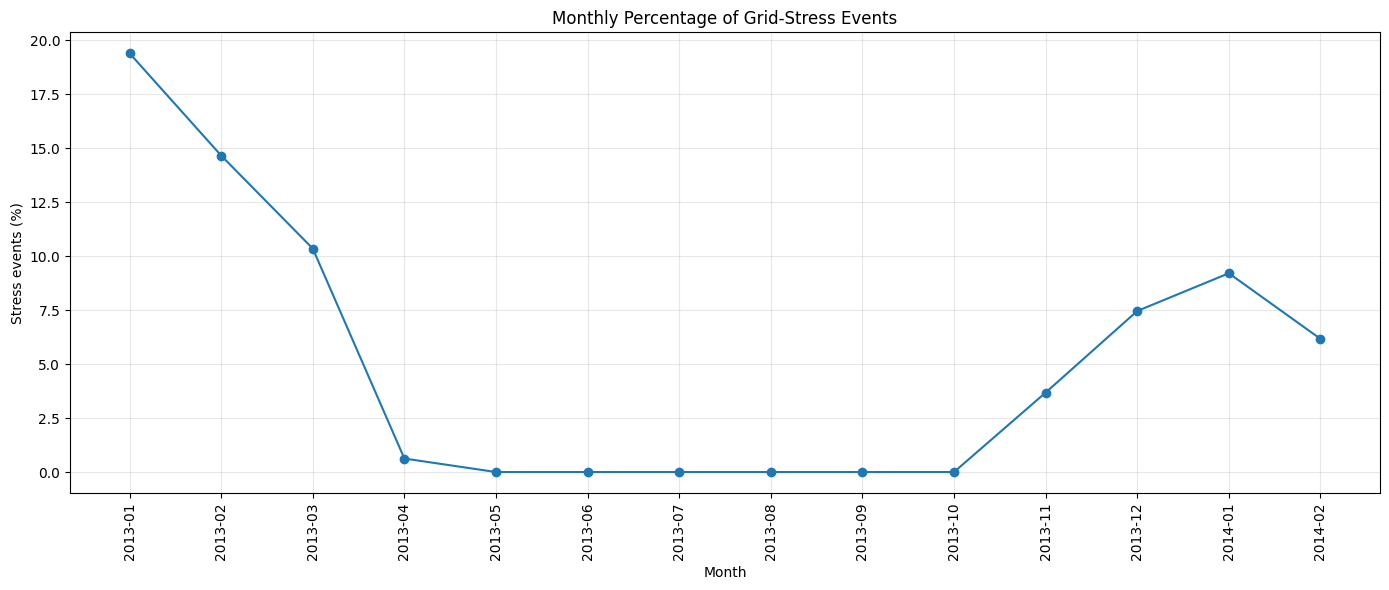

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_stress["year_month"],
    monthly_stress["stress_percentage"],
    marker="o"
)

plt.title("Monthly Percentage of Grid-Stress Events")
plt.xlabel("Month")
plt.ylabel("Stress events (%)")
plt.xticks(rotation=90)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/monthly_stress_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
neighbourhood["hour"] = neighbourhood["datetime"].dt.hour

hourly_stress = (
    neighbourhood
    .groupby("hour")
    .agg(
        total_observations=("stress_event", "size"),
        stress_events=("stress_event", "sum"),
        mean_demand_kwh=("total_demand_kwh", "mean")
    )
    .reset_index()
)

hourly_stress["stress_percentage"] = (
    hourly_stress["stress_events"]
    / hourly_stress["total_observations"]
) * 100

hourly_stress

,hour,total_observations,stress_events,mean_demand_kwh,stress_percentage
0,0,843,0,151.120810,0.000000
1,1,842,0,122.125659,0.000000
2,2,842,0,109.618043,0.000000
3,3,842,0,104.107292,0.000000
4,4,842,0,104.213645,0.000000
5,5,842,0,115.185139,0.000000
6,6,842,0,144.893590,0.000000
7,7,842,0,185.929762,0.000000
8,8,842,0,210.786441,0.000000
9,9,842,1,213.116334,0.118765


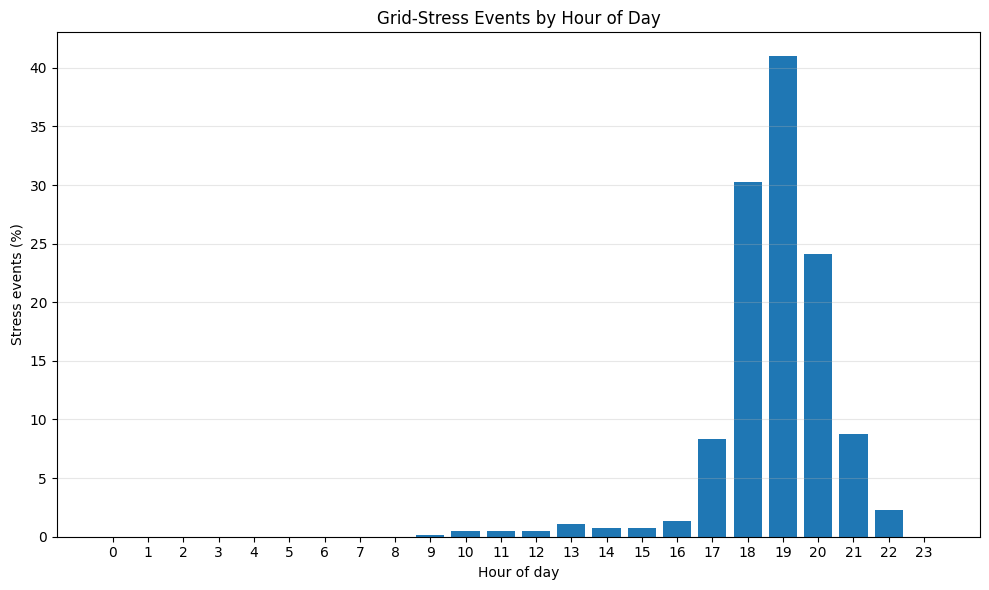

In [18]:
hourly_stress.to_csv(
    "../outputs/tables/hourly_stress_analysis.csv",
    index=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    hourly_stress["hour"],
    hourly_stress["stress_percentage"]
)

plt.title("Grid-Stress Events by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Stress events (%)")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/hourly_stress_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
neighbourhood["weekday_name"] = (
    neighbourhood["datetime"].dt.day_name()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_stress = (
    neighbourhood
    .groupby("weekday_name")
    .agg(
        total_observations=("stress_event", "size"),
        stress_events=("stress_event", "sum"),
        mean_demand_kwh=("total_demand_kwh", "mean")
    )
    .reindex(weekday_order)
    .reset_index()
)

weekday_stress["stress_percentage"] = (
    weekday_stress["stress_events"]
    / weekday_stress["total_observations"]
) * 100

weekday_stress

,weekday_name,total_observations,stress_events,mean_demand_kwh,stress_percentage
0,Monday,2880,158,202.301075,5.486111
1,Tuesday,2880,143,201.799364,4.965278
2,Wednesday,2880,126,201.092128,4.375000
3,Thursday,2928,137,200.882450,4.678962
4,Friday,2881,122,201.947248,4.234641
5,Saturday,2880,125,204.981159,4.340278
6,Sunday,2880,200,215.329081,6.944444


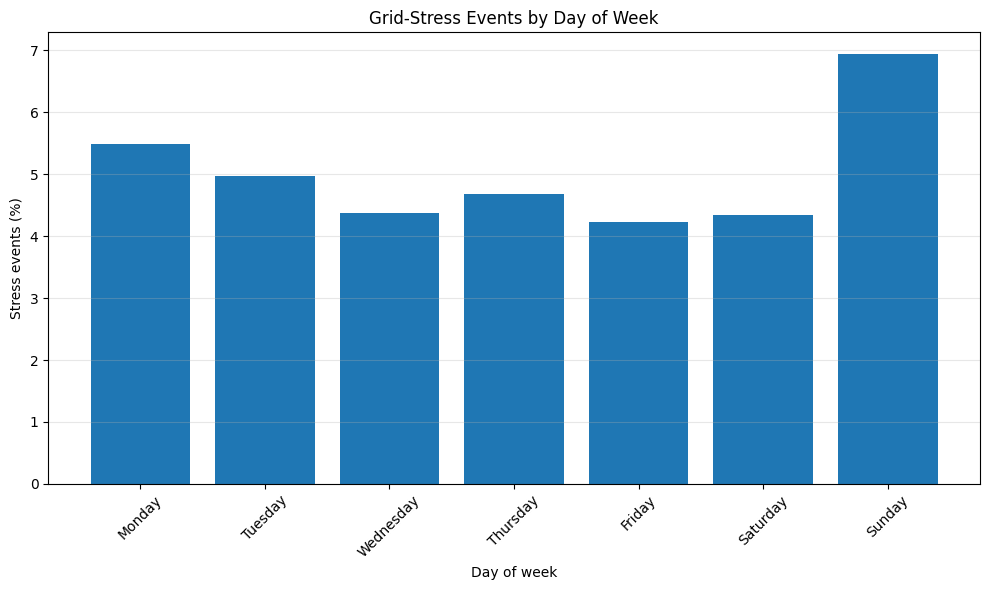

In [20]:
weekday_stress.to_csv(
    "../outputs/tables/weekday_stress_analysis.csv",
    index=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    weekday_stress["weekday_name"],
    weekday_stress["stress_percentage"]
)

plt.title("Grid-Stress Events by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Stress events (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/weekday_stress_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
top_stress_events = (
    neighbourhood[
        neighbourhood["stress_event"] == 1
    ][
        [
            "datetime",
            "total_demand_kwh",
            "stress_event"
        ]
    ]
    .sort_values(
        "total_demand_kwh",
        ascending=False
    )
    .head(20)
)

top_stress_events

,datetime,total_demand_kwh,stress_event
758,2013-01-18 19:00:00,464.916,1
1622,2013-02-05 19:00:00,458.238,1
1623,2013-02-05 19:30:00,457.803,1
757,2013-01-18 18:30:00,457.741,1
711,2013-01-17 19:30:00,454.107,1
759,2013-01-18 19:30:00,452.529,1
1624,2013-02-05 20:00:00,446.926,1
516,2013-01-13 18:00:00,445.909,1
1621,2013-02-05 18:30:00,445.888,1
710,2013-01-17 19:00:00,445.821,1


In [22]:
top_stress_events.to_csv(
    "../outputs/tables/top_20_stress_events.csv",
    index=False
)

print("Top stress events saved.")

Top stress events saved.


In [23]:
assert stress_threshold > 0
assert neighbourhood["stress_event"].isin([0, 1]).all()
assert stress_events == neighbourhood["stress_event"].sum()
assert 4.5 <= stress_percentage <= 5.5

print("All stress-detection validation checks passed.")

All stress-detection validation checks passed.


In [24]:
print("PHASE 8: STRESS DETECTION COMPLETED")
print("-----------------------------------")
print(f"Threshold method: {stress_percentile * 100:.0f}th percentile")
print(f"Stress threshold: {stress_threshold:.4f} kWh")
print(f"Total observations: {total_observations}")
print(f"Stress events: {stress_events}")
print(f"Stress percentage: {stress_percentage:.4f}%")

PHASE 8: STRESS DETECTION COMPLETED
-----------------------------------
Threshold method: 95th percentile
Stress threshold: 354.1552 kWh
Total observations: 20209
Stress events: 1011
Stress percentage: 5.0027%
